In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
dataset = pd.read_csv("Preprocessed_Chennai-Zomato-DS.csv")
dataset

,Zomato URL,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features,Price for 2,Dining Rating,Delivery Rating
0,https://www.zomato.com/chennai/yaa-mohaideen-b...,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",1500,9306,"['Home Delivery', 'Indoor Seating']",500.0,4.3,4.3
1,https://www.zomato.com/chennai/sukkubhai-biriy...,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",3059,39200,"['Home Delivery', 'Free Parking', 'Table booki...",1000.0,4.4,4.1
2,https://www.zomato.com/chennai/ss-hyderabad-bi...,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",1361,10500,"['Home Delivery', 'Indoor Seating']",500.0,4.3,4.4
3,https://www.zomato.com/chennai/kfc-perambur,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],1101,11200,"['Home Delivery', 'Free Parking', 'Card Upon D...",500.0,4.0,4.0
4,https://www.zomato.com/chennai/tasty-kitchen-p...,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",617,22400,"['Home Delivery', 'Indoor Seating']",450.0,4.2,4.1
...,...,...,...,...,...,...,...,...,...,...,...,...
12027,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,0,0,"['Breakfast', 'Delivery Only']",350.0,0.0,0.0
12028,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,0,0,"['Breakfast', 'Delivery Only']",350.0,0.0,0.0
12029,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,0,0,"['Breakfast', 'Delivery Only']",350.0,0.0,0.0
12030,https://www.zomato.com/chennai/cks-sandwiches-...,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,0,0,"['Breakfast', 'Delivery Only']",350.0,0.0,0.0


In [4]:
dataset.isna().sum()

Zomato URL               0
Name of Restaurant       0
Address                  0
Location                 0
Cuisine                  0
Top Dishes               0
Dining Rating Count      0
Delivery Rating Count    0
Features                 0
Price for 2              0
Dining Rating            0
Delivery Rating          0
dtype: int64

In [5]:
for columnName in dataset.columns:
    if dataset[columnName].dtype == 'O':
        print(columnName)
    else:
        print(columnName)

Zomato URL
Name of Restaurant
Address
Location
Cuisine
Top Dishes
Dining Rating Count
Delivery Rating Count
Features
Price for 2
Dining Rating
Delivery Rating


In [6]:
def quanqual(dataset):
    quan=[]
    qual=[]
    for columnName in dataset.columns:
        if dataset[columnName].dtype == 'O': 
            qual.append(columnName)
        else:
            quan.append(columnName)
    return quan,qual

In [7]:
quanqual(dataset)

(['Price for 2', 'Dining Rating', 'Delivery Rating'],
 ['Zomato URL',
  'Name of Restaurant',
  'Address',
  'Location',
  'Cuisine',
  'Top Dishes',
  'Dining Rating Count',
  'Delivery Rating Count',
  'Features'])

In [8]:
quan,qual = quanqual(dataset)

In [9]:
import numpy as np

descriptive=pd.DataFrame(index=["Mean", "Median", "Mode",
                                "Q1:25%","Q2:50%","Q3:75%","99%","Q4:Max",
                                "IQR","1.5Rule","Lesser_Outliers","Greater_Outliers","Min","Max","Variance","Standarad_Deviation"], columns=quan)

In [10]:
descriptive

,Price for 2,Dining Rating,Delivery Rating
Mean,NaN,NaN,NaN
Median,NaN,NaN,NaN
Mode,NaN,NaN,NaN
Q1:25%,NaN,NaN,NaN
Q2:50%,NaN,NaN,NaN
Q3:75%,NaN,NaN,NaN
99%,NaN,NaN,NaN
Q4:Max,NaN,NaN,NaN
IQR,NaN,NaN,NaN
1.5Rule,NaN,NaN,NaN


In [11]:
descriptive=pd.DataFrame(index=["Mean", "Median", "Mode",
                                "Q1:25%","Q2:50%","Q3:75%","99%","Q4:Max",
                                "IQR","1.5Rule","Lesser_Outliers","Greater_Outliers","Min","Max","Variance","Standarad_Deviation"], columns=quan)
for columnName in quan:
    #Mean,Median,Mode
    descriptive.loc["Mean", columnName] = dataset[columnName].mean()
    descriptive.loc["Median", columnName] = dataset[columnName].median()
    descriptive.loc["Mode", columnName] = dataset[columnName].mode()[0]

    #Percentile
    descriptive.loc["Q1:25%", columnName] = dataset[columnName].quantile(0.25)
    descriptive.loc["Q2:50%", columnName] = dataset[columnName].quantile(0.50)
    descriptive.loc["Q3:75%", columnName] = dataset[columnName].quantile(0.75)
    descriptive.loc["99%", columnName] = dataset[columnName].quantile(0.99)
    descriptive.loc["Q4:Max", columnName] = dataset[columnName].quantile(1.0)

    #IQR
    descriptive.loc["IQR", columnName] = descriptive.loc["Q3:75%", columnName] - descriptive.loc["Q1:25%", columnName]
    descriptive.loc["1.5Rule", columnName] = 1.5 * descriptive.loc["IQR", columnName] 
    descriptive.loc["Lesser_Outliers", columnName] = descriptive.loc["Q1:25%", columnName] - descriptive.loc["1.5Rule", columnName]
    descriptive.loc["Greater_Outliers", columnName] = descriptive.loc["Q3:75%", columnName] + descriptive.loc["1.5Rule", columnName]

    #Min,Max
    descriptive.loc["Min", columnName] = dataset[columnName].min()
    descriptive.loc["Max", columnName] = dataset[columnName].max()

    #Variance and Standard Deviation
    descriptive.loc["Variance", columnName] = dataset[columnName].var()
    descriptive.loc["Standarad_Deviation", columnName] = dataset[columnName].std()

In [12]:
descriptive

,Price for 2,Dining Rating,Delivery Rating
Mean,397.61137,1.881117,1.954829
Median,300.0,2.7,3.0
Mode,300.0,0.0,0.0
Q1:25%,200.0,0.0,0.0
Q2:50%,300.0,2.7,3.0
Q3:75%,450.0,3.5,3.9
99%,1969.0,4.4,4.4
Q4:Max,5000.0,4.9,4.7
IQR,250.0,3.5,3.9
1.5Rule,375.0,5.25,5.85


In [13]:
!pip install seaborn

In [22]:
# Dropping columns which are not required for further analysis

dataset.drop(['Zomato URL'], axis = 1, inplace=True)

In [23]:
dataset.head()

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features,Price for 2,Dining Rating,Delivery Rating
0,Yaa Mohaideen Briyani,"336 & 338, Main Road, Pallavaram, Chennai",Pallavaram,['Biryani'],"['Bread Halwa', ' Chicken 65', ' Mutton Biryan...",1500,9306,"['Home Delivery', 'Indoor Seating']",500.0,4.3,4.3
1,Sukkubhai Biriyani,"New 14, Old 11/3Q, Railway Station Road, MKN ...",Alandur,"['Biryani', ' North Indian', ' Mughlai', ' Des...","['Beef Biryani', ' Beef Fry', ' Paratha', ' Pa...",3059,39200,"['Home Delivery', 'Free Parking', 'Table booki...",1000.0,4.4,4.1
2,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",1361,10500,"['Home Delivery', 'Indoor Seating']",500.0,4.3,4.4
3,KFC,"10, Periyar Nagar, 70 Feet Road, Near Sheeba ...",Perambur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...",['Zinger Burger'],1101,11200,"['Home Delivery', 'Free Parking', 'Card Upon D...",500.0,4.0,4.0
4,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",617,22400,"['Home Delivery', 'Indoor Seating']",450.0,4.2,4.1


In [24]:
# Finding those restaurant whose has 0 Rating or Votes

useless_data = (dataset['Dining Rating'] == 0.0) | (dataset['Delivery Rating'] == 0)
dataset[useless_data]

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features,Price for 2,Dining Rating,Delivery Rating
6,Bai Veetu Kalyanam,"1/187, Thalambur Road, Navallur, Chennai",Navallur,['Biryani'],"['Bread Halwa', ' Mutton Biryani', ' Brinjal G...",Does not offer Dining,1061,['Home Delivery'],350.0,0.0,4.3
15,Welcome Hotel,"112/241, Purasawalkam High Road, Purasavakkam...",Purasavakkam,"['South Indian', ' Desserts', ' Beverages']","['Pongal', ' Podi Dosa', ' Idli Sambar', ' Vad...",1094,Does not offer Delivery,"['Breakfast', 'Vegetarian Only', 'Indoor Seati...",300.0,4.5,0.0
18,Wire Room Bar & Kitchen,"142, Phoenix Marketcity, New NGO Colony, Vela...","Phoenix Market City, Velachery","['Continental', ' Asian']","['Cocktails', ' Salad', ' Beer', ' Tikka', ' P...",354,Does not offer Delivery,"['Full Bar Available', 'Mall Parking', 'Dance ...",2000.0,4.1,0.0
23,BFF 2.0,"80/29, 2nd Main Road, RA Puram, Chennai",RA Puram,"['North Indian', ' Continental', ' Italian']","['Crispy Chicken', ' Cocktails', ' Pizza', ' N...",464,Does not offer Delivery,"['Full Bar Available', 'Indoor Seating', 'Nigh...",1500.0,4.2,0.0
77,Al Dhareeq Beef Biriyani,"64/A, 162, Sivan Kovil South Street, Kodambak...",Kodambakkam,['Biryani'],['Beef Biryani'],Does not offer Dining,19600,['Home Delivery'],300.0,0.0,3.9
...,...,...,...,...,...,...,...,...,...,...,...
12027,CK's Sandwiches,Delivery Only,Porur,['Sandwich'],Invalid,0,0,"['Breakfast', 'Delivery Only']",350.0,0.0,0.0
12028,CK's Sandwiches,Delivery Only,Kolathur,['Sandwich'],Invalid,0,0,"['Breakfast', 'Delivery Only']",350.0,0.0,0.0
12029,CK's Sandwiches,Delivery Only,Anna Nagar East,['Sandwich'],Invalid,0,0,"['Breakfast', 'Delivery Only']",350.0,0.0,0.0
12030,CK's Sandwiches,Delivery Only,Ramapuram,['Sandwich'],Invalid,0,0,"['Breakfast', 'Delivery Only']",350.0,0.0,0.0


In [25]:
## Performing Negation of the useless dataset and then storing the correct data back in the raw_df DataFrame
## This permamnently remove the wrong data from the original dataframe

dataset = dataset[~useless_data]

In [29]:
# Finding all the duplicate rows

dataset[dataset.duplicated()]

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features,Price for 2,Dining Rating,Delivery Rating


## Performing Exploratory Data Analysis

## Q1) How many restaurants are in Chennai for each type of cuisine?

In [30]:
zomato_df = dataset.copy()

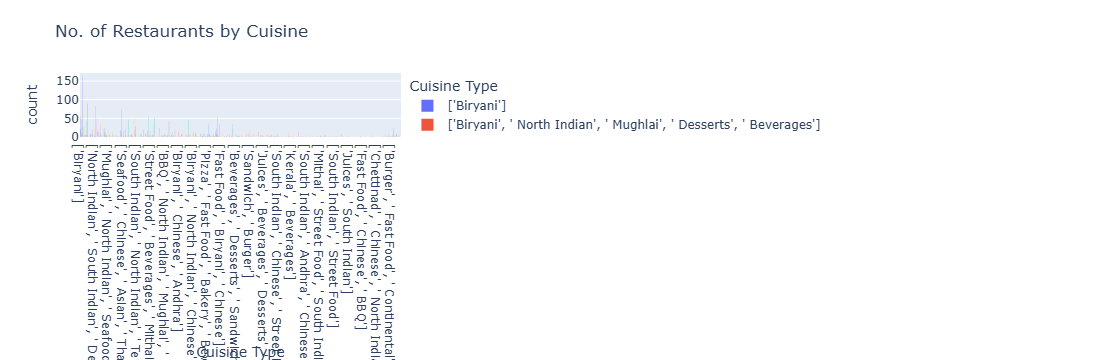

In [31]:
import plotly.express as px
import plotly.express as px
import plotly.io as pio

fig = px.histogram(
    zomato_df,
    x='Cuisine',
    color='Cuisine',
    title='No. of Restaurants by Cuisine',
    labels={'Cuisine': 'Cuisine Type'}
)

fig.show()


## Q2) What are the percentage of restaurants by Rating Type in Chennai?

In [32]:
rating_type_df = zomato_df['Dining Rating'].value_counts().reset_index()
rating_type_df.rename(columns={'index':'Dining Rating', 'Dining Rating':'COUNT OF RESTAURANTS'}, inplace=True)
rating_type_df

,COUNT OF RESTAURANTS,count
0,3.7,387
1,3.6,377
2,3.5,359
3,3.8,334
4,3.4,324
5,3.9,301
6,3.3,294
7,3.2,262
8,3.1,236
9,4.0,222


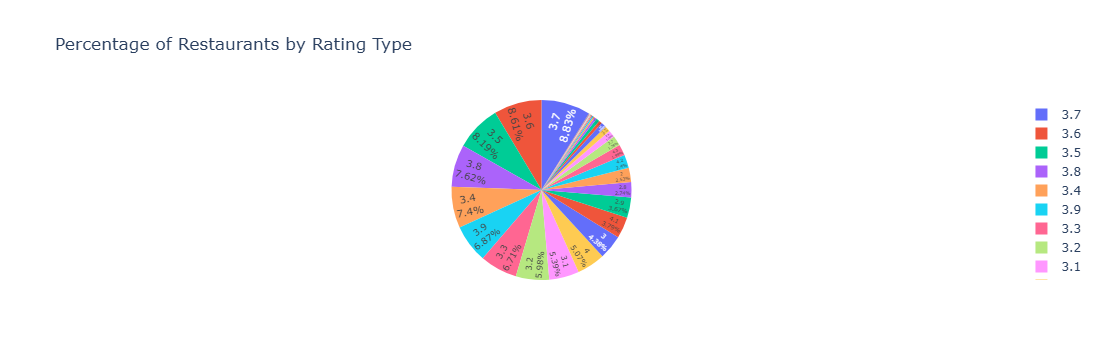

In [34]:
fig = px.pie(
    rating_type_df,
    names='COUNT OF RESTAURANTS',
    values='count',
    color='COUNT OF RESTAURANTS',
    title='Percentage of Restaurants by Rating Type'
).update_traces(textposition='inside', textinfo='percent+label')

fig.show()

## Q3) Which are the Top highest rated Seafood Restaurant in Chennai?

In [37]:
seafood_df = zomato_df[zomato_df['Top Dishes'].str.contains('Seafood')]
seafood_df.sort_values(by='Dining Rating',ascending=False).head(5)

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features,Price for 2,Dining Rating,Delivery Rating
217,Kobe Sizzlers,"1st Floor, Phoenix Market City, Velachery Mai...","Phoenix Market City, Velachery","['Continental', ' Italian', ' Chinese', ' Steak']","['Seafood Sizzler', ' Mojito', ' Lamb Chops', ...",2261,64,"['Home Delivery', 'Mall Parking', 'Indoor Seat...",1100.0,4.4,3.7


## Q4) Which is the best Food Features in Chennai?

In [41]:
foodFeatures_df = zomato_df[zomato_df['Location'] == 'Navallur']
foodFeatures_df.sort_values(by='Dining Rating',ascending=False).head(5)

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features,Price for 2,Dining Rating,Delivery Rating
43,Ghuma Ghumalu,"1/398, Rajiv Gandhi Salai, OMR, Navalur, Chennai",Navallur,"['Chinese', ' South Indian', ' Biryani', ' And...","['Hyderabadi Biryani', ' Chicken 65', ' Chicke...",1059,5961,"['Home Delivery', 'Indoor Seating', 'Table res...",500.0,4.2,3.6
8829,Sangeetha Veg Restaurant,"1A/1B, Rajiv Gandhi Salai, Navallur, Chennai",Navallur,"['South Indian', ' North Indian', ' Chinese', ...","['Filtered Coffee', ' Masala Dosa', ' Tomato S...",432,17100,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",650.0,4.2,4.0
809,Vaasu's Ghuma Ghumalu Andhra Mess,"Shop 4/9, St Thomas Street , Beside Virtusa, ...",Navallur,"['Andhra', ' South Indian', ' Chinese']","['Hyderabadi Chicken Biryani', ' Mutton Biryani']",293,5985,"['Breakfast', 'Home Delivery', 'Indoor Seating']",500.0,4.1,3.8
267,BNB Live Grill,"OMR Food Street, Navallur, Chennai",Navallur,"['North Indian', ' Chinese', ' Seafood', ' Bev...","['Turkish Coffee', ' Turkish Ice Cream', ' Bir...",777,176,"['Home Delivery', 'Free Parking', 'Table booki...",750.0,4.1,3.1
8808,KFC,"33, Coromandal Plaza, OMR Road, Navallur, Che...",Navallur,"['Burger', ' Fast Food', ' Finger Food', ' Bev...","['Burgers', ' Choco Lash', ' Hot Wings', ' Chi...",867,11,"['Home Delivery', 'Indoor Seating', 'Card Upon...",500.0,4.1,4.0


## Q5) Which places have the highest rated restaurant for each Cuisine Type in Chennai?

In [42]:
# Assuming restaurants having rating above 4.5

highest_rated_df = zomato_df[zomato_df['Dining Rating'] >= 4.5]
highest_rated_df.head(5)

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features,Price for 2,Dining Rating,Delivery Rating
24,Eating Circles,"6, CP Ramaswamy Road, Alwarpet, Chennai",Alwarpet,['South Indian'],"['Rose Milk', ' Neer Dosa', ' Thatte Idli', ' ...",782,2744,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",250.0,4.7,4.2
37,Shree Mithai,"18, Dr TV Road, Chetpet, Chennai",Chetpet,"['Mithai', ' Street Food', ' Fast Food']","['Chaat', ' Badam Milk', ' Pav Bhaji', ' Panip...",1085,18600,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",300.0,4.6,4.4
50,Andhikkadai,"20, Dhandeeswaram Main Road, Velachery, Chennai",Velachery,['South Indian'],"['Coffee', ' Sweet Kozhukattai', ' Idli', ' Po...",908,17300,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",200.0,4.6,4.2
57,Brownie Heaven,"193, Peters Road, Opposite New College, Royap...",Royapettah,"['Bakery', ' Desserts', ' Beverages']","['Vanilla Ice Cream', ' Brownie Shake', ' Filt...",842,2270,"['Home Delivery', 'Indoor Seating', 'Desserts ...",350.0,4.9,4.3
59,Mezze,"Abhinav Center, Old Number 19, New Number 4, ...",Alwarpet,['Middle Eastern'],"['Baklava', ' Mezze', ' Shawarma', ' Pita Brea...",1152,2249,"['Home Delivery', 'Indoor Seating']",700.0,4.7,4.2


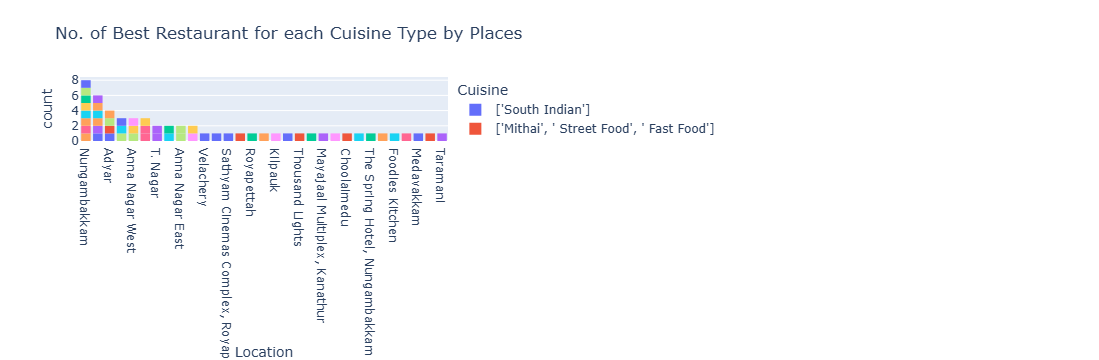

In [43]:
fig = px.histogram(
    highest_rated_df,
    x='Location',
    color='Cuisine',
    title='No. of Best Restaurant for each Cuisine Type by Places'
).update_xaxes(categoryorder="total descending")

fig.show()

## Q6) What is the Avg Price Distibution of highest rated restaurant for each Cuisine Type in Chennai?

In [44]:
highest_rated_price_df = highest_rated_df.groupby(by=['Location', 'Cuisine'])['Price for 2'].mean().reset_index()
highest_rated_price_df.head()

,Location,Cuisine,Price for 2
0,Adyar,"['Chinese', ' Thai']",800.0
1,Adyar,['Ice Cream'],200.0
2,Adyar,"['North Indian', ' Chettinad', ' Mughlai', ' D...",1800.0
3,Adyar,['South Indian'],500.0
4,Alwarpet,"['Desserts', ' Ice Cream']",350.0


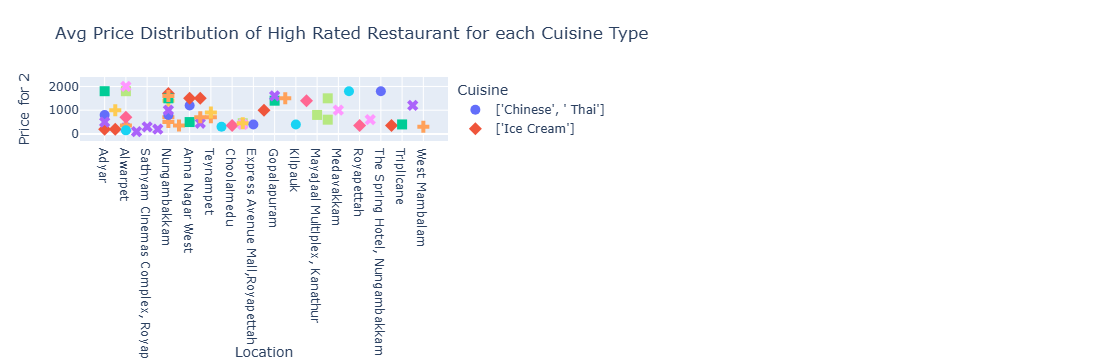

In [45]:
fig = px.scatter(
    highest_rated_price_df,
    x="Location",
    y="Price for 2",
    color="Cuisine",
    symbol="Cuisine",
    title='Avg Price Distribution of High Rated Restaurant for each Cuisine Type'
).update_traces(marker_size=10)

fig.show()

## Q7) Which areas have a large number of Chinese Restaurant ?¶

In [48]:
chinese_df = zomato_df[zomato_df['Cuisine'].str.contains('Chinese')].head(5)
chinese_df

,Name of Restaurant,Address,Location,Cuisine,Top Dishes,Dining Rating Count,Delivery Rating Count,Features,Price for 2,Dining Rating,Delivery Rating
2,SS Hyderabad Biryani,"98/339, Arcot Road, Opposite Gokulam Chit Fun...",Kodambakkam,"['Biryani', ' North Indian', ' Chinese', ' Ara...","['Brinjal Curry', ' Tandoori Chicken', ' Chick...",1361,10500,"['Home Delivery', 'Indoor Seating']",500.0,4.3,4.4
4,Tasty Kitchen,"135B, SRP Colony, Peravallur, Near Perambur, ...",Perambur,"['Chinese', ' Biryani', ' North Indian', ' Che...","['Mutton Biryani', ' Chicken Rice', ' Tomato R...",617,22400,"['Home Delivery', 'Indoor Seating']",450.0,4.2,4.1
5,Dine N Fun,"Opposite Forest Office, Tambaram Main Road, S...",Medavakkam,"['South Indian', ' North Indian', ' Chinese']","['Chicken Grill', ' Shawarma', ' Naan', ' Chic...",567,24700,"['Home Delivery', 'Indoor Seating']",450.0,4.1,3.8
8,Savoury Sea Shell,"3, E Block, 3rd Avenue, Anna Nagar East, Chennai",Anna Nagar East,"['Arabian', ' Chinese', ' North Indian', ' Leb...","['Shawarma', ' Chicken Grill', ' Brownie', ' S...",2564,21700,"['Home Delivery', 'Indoor Seating', 'Card Upon...",1400.0,4.2,4.1
9,Sangeetha Veg Restaurant,"102/82, GN Chetty Road, T. Nagar, Chennai",T. Nagar,"['South Indian', ' North Indian', ' Chinese', ...","['Filtered Coffee', ' Chaat', ' Faluda', ' Mas...",1578,39600,"['Breakfast', 'Home Delivery', 'Vegetarian Onl...",800.0,4.4,4.2


In [51]:
chinese_rest_df = (
    chinese_df
    .groupby(by='Location')
    .agg({'Name of Restaurant': 'count', 'Price for 2': 'mean'})
    .rename(columns={'Name of Restaurant': 'COUNT OF RESTAURANTS', 'Price for 2': 'AVG_PRICE'})
)

chinese_rest_df = chinese_rest_df.sort_values('COUNT OF RESTAURANTS', ascending=False).head(25)

chinese_rest_df.head()

,COUNT OF RESTAURANTS,AVG_PRICE
Location,,
Anna Nagar East,1,1400.0
Kodambakkam,1,500.0
Medavakkam,1,450.0
Perambur,1,450.0
T. Nagar,1,800.0


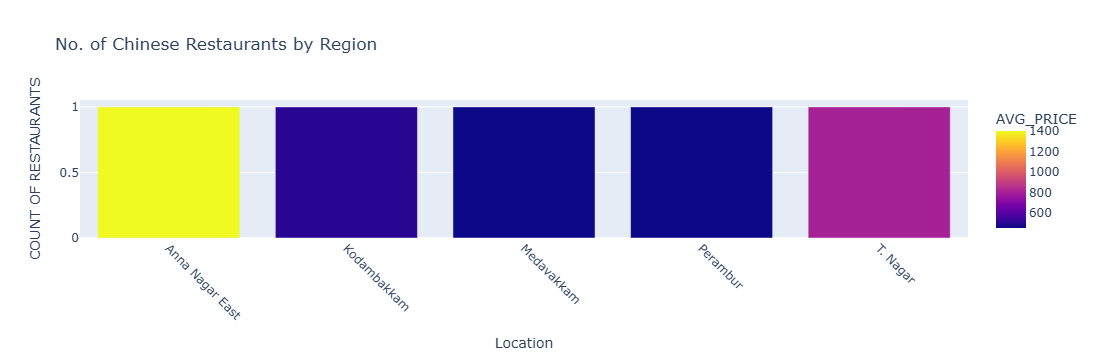

In [56]:
fig = px.bar(
    chinese_rest_df,
    x=chinese_rest_df.index,     
    y='COUNT OF RESTAURANTS',
    color='AVG_PRICE',
    title='No. of Chinese Restaurants by Region'
)

fig.update_xaxes(categoryorder='total descending', tickangle=45)
fig.show()


## Q8) Is there a relation between Price and Rating by each Cuisine Type?

In [57]:
price_rating_df = zomato_df.groupby(['Cuisine', 'Dining Rating'])['Price for 2'].mean().reset_index()
price_rating_df

,Cuisine,Dining Rating,Price for 2
0,"['American', ' Continental', ' European', ' It...",3.9,700.0
1,"['American', ' Continental', ' Italian', ' Nor...",4.1,800.0
2,"['American', ' Continental']",4.1,1600.0
3,"['American', ' Fast Food']",2.7,300.0
4,"['American', ' Fast Food']",3.9,500.0
...,...,...,...
2891,"['Tibetan', ' Momos']",3.1,400.0
2892,"['Tibetan', ' Momos']",3.4,400.0
2893,"['Tibetan', ' Momos']",3.5,400.0
2894,"['Tibetan', ' Momos']",3.6,400.0


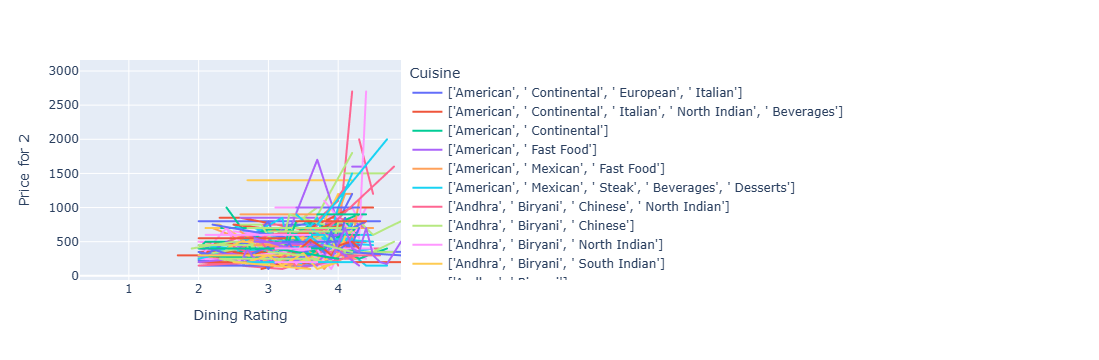

In [58]:
fig = px.line(price_rating_df, y="Price for 2", x="Dining Rating",color='Cuisine')
fig.show()

## Q9) Is there a relation between Location and Price?

In [59]:
region_price_df = zomato_df.groupby(['Location'])['Price for 2'].mean().reset_index()
region_price_df

,Location,Price for 2
0,Abhiramapuram,200.000000
1,Adambakkam,327.631579
2,Adyar,528.865979
3,Akkarai,575.000000
4,Alandur,442.857143
...,...,...
156,Vepery,347.368421
157,Vettuvankeni,475.000000
158,Virugambakkam,422.000000
159,Washermenpet,380.555556


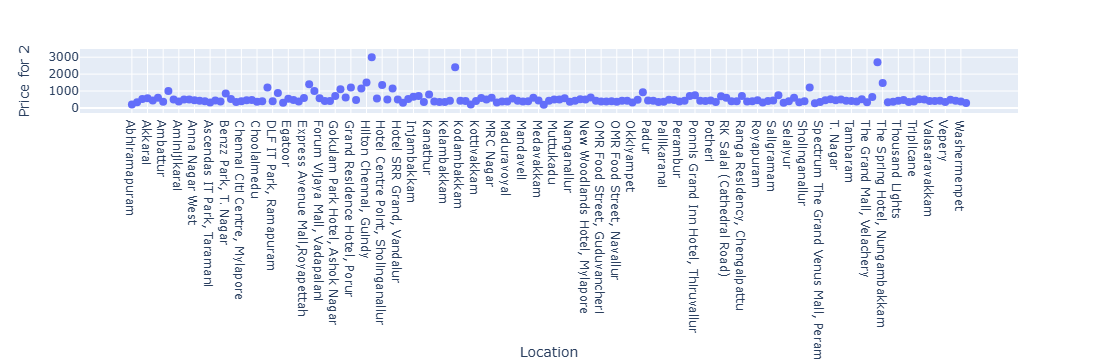

In [60]:
fig = px.scatter(region_price_df, x="Location", y="Price for 2").update_traces(marker_size=8)
fig.show()

## Q10) Find the list of Affordable Restaurants

In [61]:
max_price = zomato_df['Price for 2'].max()
one_fourth_price = max_price/4
one_fourth_price

750.0

In [63]:
# Finding list of restaurants that have price less than and equal to 1/4th of the max price i.e Finding Cheap Restauran

aff_rest_df = zomato_df[['Name of Restaurant', 'Price for 2', 'Cuisine', 'Location', 'Features']]
aff_rest_df = aff_rest_df[aff_rest_df['Price for 2'] <= 1250]
aff_rest_df.sort_values(by='Price for 2', inplace=True)
aff_rest_df

,Name of Restaurant,Price for 2,Cuisine,Location,Features
2511,Rose Milk Raja,100.0,['Beverages'],Maduravoyal,"['Home Delivery', 'Indoor Seating']"
2645,Black Pekoe Tea,100.0,['Tea'],Velachery,"['Home Delivery', 'Indoor Seating']"
2278,Prithvika Fast Food,100.0,"['South Indian', ' Chinese']",Ramapuram,"['Home Delivery', 'Indoor Seating']"
2820,Devasahayam Pillai Enterprises,100.0,['South Indian'],Adyar,"['Breakfast', 'Home Delivery', 'Vegetarian Onl..."
2151,Cane 4 U,100.0,['Beverages'],Besant Nagar,"['Home Delivery', 'Indoor Seating']"
...,...,...,...,...,...
504,Goddy's,1200.0,"['Cafe', ' Continental', ' Italian', ' Fast Fo...",Nungambakkam,"['Breakfast', 'Home Delivery', 'LGBTQIA Friend..."
473,Dynasty,1200.0,"['Chinese', ' Seafood']","Harrisons Hotel, Nungambakkam","['Home Delivery', 'Full Bar Available', 'Valet..."
582,Quintessence - Hotel Raj Park Chennai,1200.0,"['North Indian', ' Continental']","Hotel Rajpark, Alwarpet","['Breakfast', 'Home Delivery', 'Wheelchair Acc..."
541,Yaki BBQ,1200.0,"['Biryani', ' North Indian', ' BBQ', ' South I...",Perungudi,"['Home Delivery', 'Free Parking', 'Table booki..."
